# Session 2 — Map your spinal cord to the mouse whole brain (MapMyCells)

**Lipari Genomics Workshop 2026 — Interactive Part 2B (Map to whole brain)**

In Session 1 you built a spinal-cord (SpC) cell-type taxonomy. Here you take that
dataset to the **[MapMyCells web portal](https://knowledge.brain-map.org/mapmycells/process)**,
map every nucleus onto the **Allen mouse whole-brain** atlas (10x Whole Mouse
Brain, `CCN20230722`), and ask **where in the mouse brain** your spinal cell types
turn up — by projecting onto the ABC mouse-brain **MERFISH spatial atlas**.

The notebook is in two parts:

1. **Forward mapping (this is the main event).** Load your MapMyCells download,
   see **which whole-brain subclasses** your spinal cord maps to, pick out the
   **most common neuron types**, and **paint them onto the brain** in space. *This
   half is **dataset-agnostic** — drop in any `.h5ad` mapped to the whole mouse
   brain and it just works.*
2. **Reciprocal refinement (optional, at the end).** Mapping can never say *"none
   of the above"*, so a one-way map will happily assign spinal labels to cortex.
   Mapping **both** ways and keeping the pairs that agree sharpens sensitivity and
   specificity. We work through that afterwards.

> All seeds are fixed. The only thing you change to use **your own** data is the
> `PORTAL_OUTPUT` path in §0. The forward half (§1–§4) then runs on **any**
> whole-mouse-brain MapMyCells result; the reciprocal half (§5+) is specific to the
> Session-1 spinal-cord taxonomy.
>
> The mouse whole-brain **MERFISH spatial atlas** used below is pre-downloaded for
> you. If you ever need to fetch or rebuild it yourself, the download script is
> [`session2/processing/00_download_spatial_atlas.py`](../processing/00_download_spatial_atlas.py)
> (`/code/lipari_genomics_workshop_2026/session2/processing/00_download_spatial_atlas.py`),
> which pulls it straight from the Allen Brain Cell (ABC) Atlas S3 bucket.

### Before you start: get your MapMyCells results

You need to run the mapping on the web portal **once** and bring the results back
into Code Ocean. It takes about five minutes:

1. **Download the query `.h5ad`.** In the Code Ocean file browser, find

   ```
   /data/lipari_workshop/SpC_workshop_snRNA_session2_clean.h5ad
   ```

   **right-click it → Download** to save it to your laptop.
2. **Upload it to MapMyCells.** Open the
   **[MapMyCells web portal](https://knowledge.brain-map.org/mapmycells/process)**
   and upload the `.h5ad` you just downloaded.
3. **Select the taxonomy.** Choose the reference
   **"10x Whole Mouse Brain (CCN20230722)"** and the **"Hierarchical"** mapping
   algorithm, then **Run**.
4. **Download the results.** When the job finishes, **download the results
   `.zip`** (it contains a `…HierarchicalMapping….csv`).
5. **Bring it back to Code Ocean.** **Drag and drop** that `.zip` from your laptop
   into the Code Ocean file browser to upload it, then set `PORTAL_OUTPUT` in §0 to
   its path.

## 0. Setup

Import libraries, **fix all random seeds**, and — most importantly — point
`PORTAL_OUTPUT` at **your** MapMyCells results download. The forward half (§1–§4)
needs only that download plus the mouse-brain **MERFISH spatial atlas**, so it runs
on **any** dataset mapped to the whole mouse brain. The Session-1 spinal references
(your V2 taxonomy + the reverse map) are loaded later, in §5, since only the
optional reciprocal half uses them.

In [1]:
import os, sys, io, json, zipfile, glob, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 0
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
sc.settings.seed = SEED
sc.settings.verbosity = 1

# Mapping helpers live with the Session-2 processing scripts.
PROC_DIR = '/code/lipari_genomics_workshop_2026/session2/processing'
sys.path.insert(0, PROC_DIR)
import mapping_io as mio

# ============================================================================
# >>> STUDENTS: point this at YOUR MapMyCells results download <<<
# After you map your Session-1 h5ad on https://knowledge.brain-map.org/mapmycells
# (reference = "10x Whole Mouse Brain (CCN20230722)", algorithm = "Hierarchical"),
# download the results .zip and set PORTAL_OUTPUT to it. The loader accepts the
# .zip itself, the unzipped folder, or the HierarchicalMapping *.csv inside.
PORTAL_OUTPUT = ('/data/lipari_workshop/SpC_workshop_snRNA_session2_clean(1)_'
                 '10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_'
                 'UTC_1782861326789.zip')
# ============================================================================

# --- Forward-mapping reference data (shared; you do NOT change these) -----------
# The forward half of this notebook (§1-§4) is DATASET-AGNOSTIC: hand it ANY
# MapMyCells 'Hierarchical' result mapped to 10x Whole Mouse Brain (CCN20230722)
# plus this mouse-brain MERFISH atlas and it runs -- no spinal-cord data required.
SPATIAL_ATLAS   = ('/data/mouse_wb_spatial_tutorial/reference/spatial_atlas/'
                   'C57BL6J-638850-16good-sections-raw-meta.h5ad')

WB_SUBCLASS_LEVEL = 'subclass_label'   # forward result level (mouse WB)
WB_SUPERTYPE_LEVEL = 'supertype_label' # finer forward level (mouse WB)
ATLAS_SUBCLASS    = 'subclass'         # atlas .obs column
ATLAS_SUPERTYPE   = 'supertype'        # atlas .obs column (finer level)
MIN_PROB          = 0.50               # min bootstrapping probability to keep a mapping

# The Session-1 spinal-cord references (your query labels + the reverse map) are
# needed only for the OPTIONAL reciprocal half and are loaded in §5, so the forward
# story stays dataset-agnostic.

for p in [PORTAL_OUTPUT, SPATIAL_ATLAS]:
    print(f"{'OK ' if os.path.exists(p) else 'MISSING'} {p}")

OK  /data/lipari_workshop/SpC_workshop_snRNA_session2_clean(1)_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1782861326789.zip
OK  /data/mouse_wb_spatial_tutorial/reference/spatial_atlas/C57BL6J-638850-16good-sections-raw-meta.h5ad


## 1. The MapMyCells mapping (web portal)

You produced `PORTAL_OUTPUT` on the web portal in four clicks:

1. Go to **[MapMyCells](https://knowledge.brain-map.org/mapmycells/process)** and
   **upload** your Session-1 spinal-cord `.h5ad` (raw counts; genes as symbols).
2. Choose the reference taxonomy **"10x Whole Mouse Brain (CCN20230722)"**.
3. Choose the **"Hierarchical"** mapping algorithm and **Run**.
4. **Download** the results — a `.zip` containing a `…HierarchicalMapping….csv`.

That CSV has one row per nucleus with its assigned whole-brain **class / subclass /
supertype / cluster** and a **bootstrapping probability** (confidence) at each
level. The loader below reads it straight out of the `.zip` (or a folder / `.csv`),
so swapping in your own download is a one-line change.

In [2]:
def load_portal_mapping(path):
    """Read a MapMyCells 'HierarchicalMapping' result into a tidy per-cell frame.

    Accepts the downloaded .zip, the unzipped folder, or the *.csv directly.
    Returns a DataFrame indexed by cell_id with, for each taxonomy level,
    '<level>_label' (the assigned name) and '<level>_label_prob' (bootstrapping
    probability) -- matching the column convention the mapping helpers expect.
    """
    if path.endswith('.zip'):
        with zipfile.ZipFile(path) as zf:
            name = [n for n in zf.namelist()
                    if n.endswith('.csv') and 'Mapping' in n][0]
            raw = zf.read(name).decode()
    elif os.path.isdir(path):
        name = [f for f in glob.glob(os.path.join(path, '*.csv'))
                if 'Mapping' in os.path.basename(f)][0]
        raw = open(name).read()
    else:
        raw = open(path).read()
    # The portal prepends 4 comment lines (taxonomy hierarchy, algorithm, ...).
    df = pd.read_csv(io.StringIO(raw), comment='#')
    out = pd.DataFrame({'cell_id': df['cell_id']})
    for lv in ['class', 'subclass', 'supertype', 'cluster']:
        out[f'{lv}_label'] = df[f'{lv}_name'].values
        out[f'{lv}_label_prob'] = df[f'{lv}_bootstrapping_probability'].values
    return out.set_index('cell_id')


mapping_df = load_portal_mapping(PORTAL_OUTPUT)
print(mapping_df.shape[0], 'cells mapped to the mouse whole brain')
mapping_df.head()

35104 cells mapped to the mouse whole brain


,class_label,class_label_prob,subclass_label,subclass_label_prob,supertype_label,supertype_label_prob,cluster_label,cluster_label_prob
cell_id,,,,,,,,
AAACATGCACAAAGAC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,24 MY Glut,0.82,245 SPVI-SPVC Tlx3 Ebf3 Glut,0.53,0984 SPVI-SPVC Tlx3 Ebf3 Glut_4,0.52,4433 SPVI-SPVC Tlx3 Ebf3 Glut_4,0.42
AAACCGAAGCACCACA-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,30 Astro-Epen,0.96,318 Astro-NT NN,0.87,1159 Astro-NT NN_1,0.89,5212 Astro-NT NN_1,0.76
AAAGCGGGTCCAAGAC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,19 MB Glut,0.19,168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut,0.38,0724 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut_7,0.31,2987 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut_7,0.14
AACCGCTCAAGCGAGC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,24 MY Glut,0.99,257 SPVC Ccdc172 Glut,0.58,1020 SPVC Ccdc172 Glut_1,1.00,4585 SPVC Ccdc172 Glut_1,0.63
AACCTCCTCGACAAAG-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,30 Astro-Epen,0.78,318 Astro-NT NN,0.69,1160 Astro-NT NN_2,0.98,5214 Astro-NT NN_2,0.67


## 2. The mouse whole-brain reference in space — what we're working with

Before asking *where* our cells map, let's meet the **reference**: the ABC
mouse-brain **MERFISH** atlas (16 clean sections, ~1.2 M cells). Each cell carries
its whole-brain **subclass** / **supertype** and a **CCF region**, so we can see the
whole brain — its cell types *and* its anatomy — laid out in space. This is the
canvas we will project the mapping onto. `build_spatial_reference` also returns each
subclass's **spatial specificity** (1 − fraction of sections it appears in) so we can
later down-weight ubiquitous types.

In [3]:
adata_atlas, specificity = mio.build_spatial_reference(
    SPATIAL_ATLAS, subclass_key=ATLAS_SUBCLASS)
print(adata_atlas.shape)
print('\nMost spatially specific subclasses:')
print(specificity.sort_values(ascending=False).head(8))

(1215217, 550)

Most spatially specific subclasses:
subclass
236 IRN Vip Glut         0.9375
262 Pineal Crx Glut      0.9375
260 MDRNv Crp Glut       0.9375
253 IO Fgl2 Glut         0.9375
280 NLL-po Pax7 Gaba     0.9375
241 NTS Mbnl3 Glut       0.9375
096 PVHd Gsc Gaba        0.9375
239 MARN-GRN Pyy Glut    0.9375
Name: spatial_specificity, dtype: float64


### Lay the sections out on a grid

The 16 MERFISH sections overlap in raw coordinates; tile them into a montage so we
can view the whole brain at once. (Helper adapted from the spatial tutorial.)

In [4]:
def tile_sections_on_grid(adata, section_key='brain_section_label',
                          spatial_key='spatial_grid', pad=0.0, new_key='spatial_tiled'):
    coords = np.asarray(adata.obsm[spatial_key])
    if isinstance(adata.obs[section_key].dtype, pd.CategoricalDtype):
        sections = list(adata.obs[section_key].cat.categories)
    else:
        sections = list(pd.unique(adata.obs[section_key]))
    centers, widths, heights = {}, [], []
    for s in sections:
        m = (adata.obs[section_key].values == s); sc_ = coords[m]
        if sc_.size == 0:
            centers[s] = np.array([0., 0.]); widths.append(0.); heights.append(0.); continue
        cmin, cmax = sc_.min(0), sc_.max(0)
        widths.append(cmax[0]-cmin[0]); heights.append(cmax[1]-cmin[1]); centers[s] = sc_.mean(0)
    tile_w = (max(widths) if widths else 0.) + pad
    tile_h = (max(heights) if heights else 0.) + pad
    n_cols = int(np.ceil(np.sqrt(len(sections))))
    new = coords.copy()
    for i, s in enumerate(sections):
        r, c = i // n_cols, i % n_cols
        m = (adata.obs[section_key].values == s)
        new[m] = coords[m] + (np.array([c*tile_w, r*tile_h], float) - centers[s])
    adata.obsm[new_key] = new


def plot_section(xx, yy, cc=None, val=None, cmap=None, s=0.5, alpha=1.0,
                 fig_width=12, fig_height=12, title=None):
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    if cmap is not None:
        sct = ax.scatter(xx, yy, s=s, c=val, marker='.', cmap=cmap, alpha=alpha)
    else:
        sct = ax.scatter(xx, yy, s=s, color=cc, marker='.', alpha=alpha)
    ax.axis('equal'); ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)
    return fig, ax, sct

tile_sections_on_grid(adata_atlas, pad=0.0)
adata_atlas.obsm['spatial_tiled'][:, 1] *= -1            # flip y so the brain is upright
adata_atlas.obs['x'] = adata_atlas.obsm['spatial_tiled'][:, 0]
adata_atlas.obs['y'] = adata_atlas.obsm['spatial_tiled'][:, 1]
print('tiled', adata_atlas.n_obs, 'cells across',
      adata_atlas.obs['brain_section_label'].nunique(), 'sections')

tiled 1215217 cells across 16 sections


### The atlas's own cell types **and** regions in space

For orientation, two views of the atlas's **own** annotations. **First:** every
neuron drawn in its own **subclass** colour (we drop the ubiquitous `… NN`
non-neuronal subclasses that blanket the whole brain). **Second:** every cell
coloured by its finer **CCF region** (`parcellation_structure`) so anatomical
boundaries — cortical areas, thalamic and hypothalamic nuclei, hindbrain
structures — are visible. This is the canvas we will project the spinal mapping
onto.

684705 neuronal atlas cells; 314 subclasses, 1147 supertypes


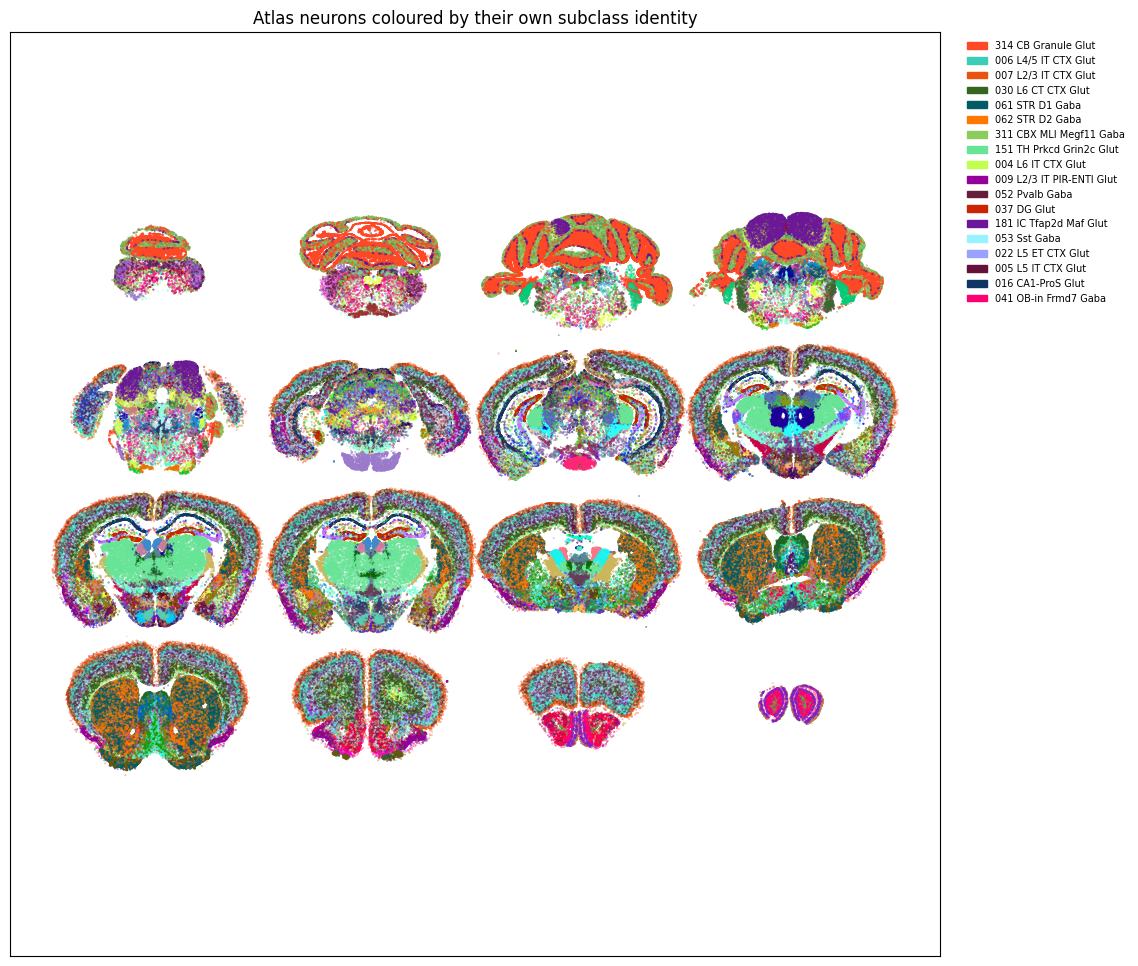

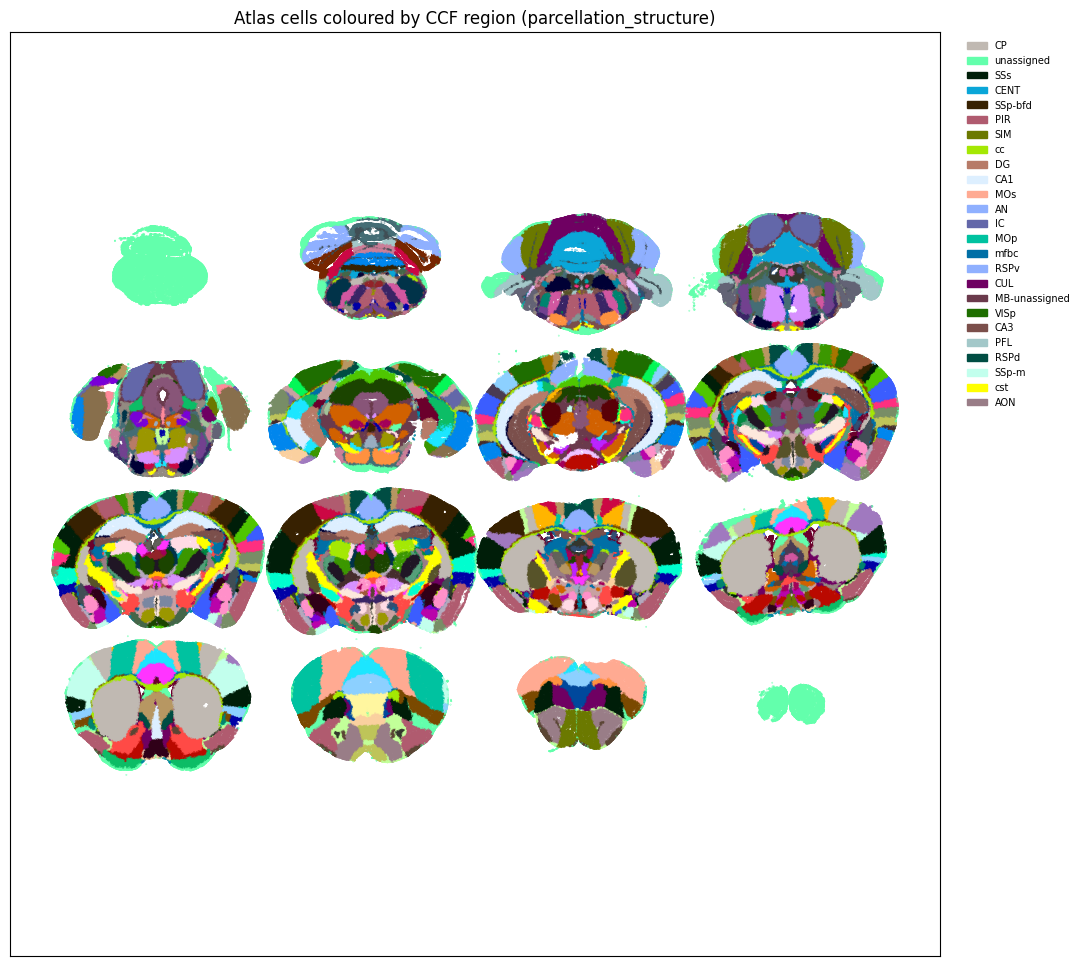

In [5]:
def plot_identities(obs, color_col, label_col, title, n_legend=18, s=0.25):
    """Montage coloured by an atlas annotation's own per-cell *_color column,
    with a legend of the most common identities."""
    import matplotlib.patches as mpatches
    fig, ax, _ = plot_section(obs['x'], obs['y'], cc=obs[color_col].values, s=s,
                              title=title)
    top = obs[label_col].astype(str).value_counts().head(n_legend).index
    cmap = dict(zip(obs[label_col].astype(str), obs[color_col].astype(str)))
    ax.legend(handles=[mpatches.Patch(color=cmap[v], label=v) for v in top],
              bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
    plt.show()

neuron_obs = adata_atlas.obs[
    ~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)].copy()
print(neuron_obs.shape[0], 'neuronal atlas cells;',
      neuron_obs['subclass'].nunique(), 'subclasses,',
      neuron_obs['supertype'].nunique(), 'supertypes')
plot_identities(neuron_obs, 'subclass_color', 'subclass',
                'Atlas neurons coloured by their own subclass identity')

# Anatomy: ALL cells coloured by CCF region at the finer **structure** level
# (parcellation_structure). The atlas's own colours reuse near-white/grey shades,
# so recolour with scanpy's high-contrast godsnot_102 palette (cycled, since there
# are more structures than palette colours).
_regs = adata_atlas.obs['parcellation_structure'].astype('category').cat.categories
_pal = sc.pl.palettes.godsnot_102
_reg_colors = {r: _pal[i % len(_pal)] for i, r in enumerate(_regs)}
adata_atlas.obs['region_color'] = (
    adata_atlas.obs['parcellation_structure'].astype(str).map(_reg_colors))
plot_identities(adata_atlas.obs, 'region_color', 'parcellation_structure',
                'Atlas cells coloured by CCF region (parcellation_structure)', n_legend=25)

## 3. Which whole-brain **subclasses** did the spinal cord map to?

The bar chart shows the mouse whole-brain subclasses your spinal cord maps to most
often. Expect **hindbrain / spinal-trigeminal** types (e.g. `SPVI-SPVC …`) — the
brainstem continuation of the dorsal horn — alongside the ubiquitous non-neuronal
classes (Oligo, Astro, Microglia), which exist everywhere including the spinal cord.

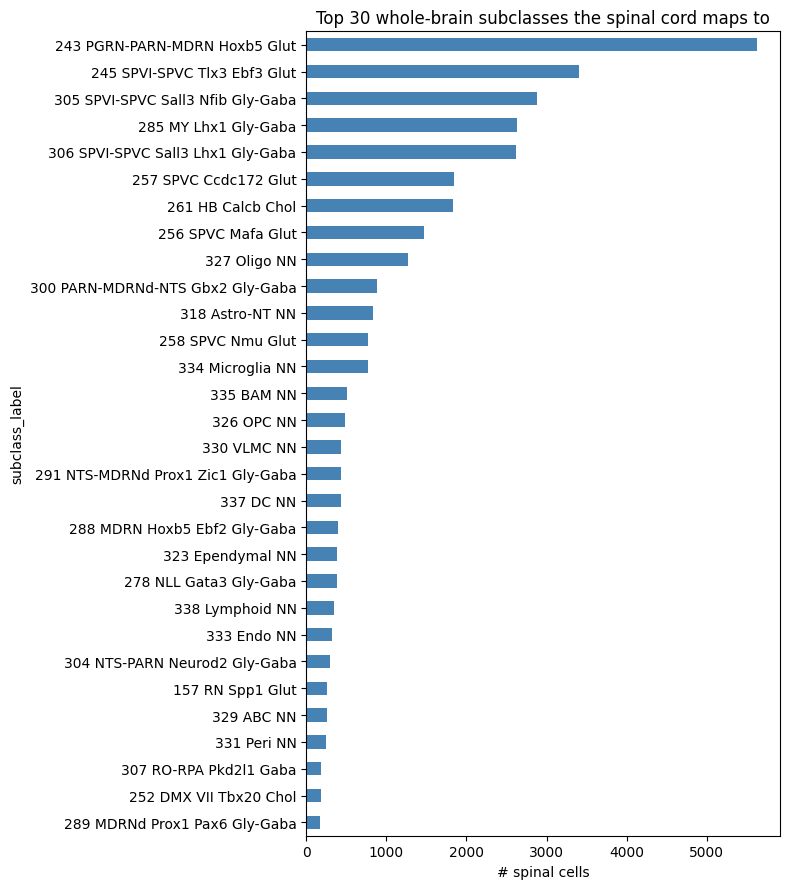

216 distinct mouse-WB subclasses detected.


In [6]:
counts = mapping_df[WB_SUBCLASS_LEVEL].value_counts()
fig, ax = plt.subplots(figsize=(8, 9))
counts.head(30)[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('# spinal cells'); ax.set_title('Top 30 whole-brain subclasses the spinal cord maps to')
plt.tight_layout(); plt.show()
print(f"{(counts > 0).sum()} distinct mouse-WB subclasses detected.")

### Mapping confidence — and a confidence filter

The per-cell **bootstrapping probability** (0–1) is the portal's own confidence
score: how stable each assignment is across resampled marker sets. We **keep only
assignments with probability ≥ `MIN_PROB` (= 0.5)** so the rest of the analysis is
built from confident calls rather than coin-flips.

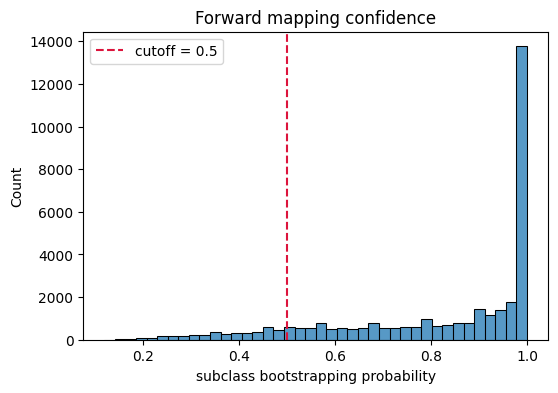

median confidence: 0.93
kept 31234 / 35104 spinal cells (89.0%) at prob >= 0.5


In [7]:
prob_col = f'{WB_SUBCLASS_LEVEL}_prob'
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(mapping_df[prob_col], bins=40, ax=ax)
ax.axvline(MIN_PROB, color='crimson', ls='--', lw=1.5, label=f'cutoff = {MIN_PROB}')
ax.set_xlabel('subclass bootstrapping probability')
ax.set_title('Forward mapping confidence'); ax.legend()
plt.show()
print('median confidence:', round(float(mapping_df[prob_col].median()), 3))

# Keep only confident assignments (bootstrapping probability >= MIN_PROB).
n_before = len(mapping_df)
mapping_df = mapping_df[mapping_df[prob_col] >= MIN_PROB].copy()
print(f'kept {len(mapping_df)} / {n_before} spinal cells '
      f'({len(mapping_df) / n_before:.1%}) at prob >= {MIN_PROB}')

### The most common **neuron** types

The whole-brain reference is mostly the **brain**, so non-neuronal subclasses
(`… NN`: Astro, Oligo, Microglia, Vascular …) map abundantly but tell us little
about neuronal identity — they look the same everywhere. Drop them to reveal the
**neuronal** whole-brain types your spinal cord most resembles, at both the
**subclass** and finer **supertype** level.

25107 / 31234 confident cells map to a NEURON subclass


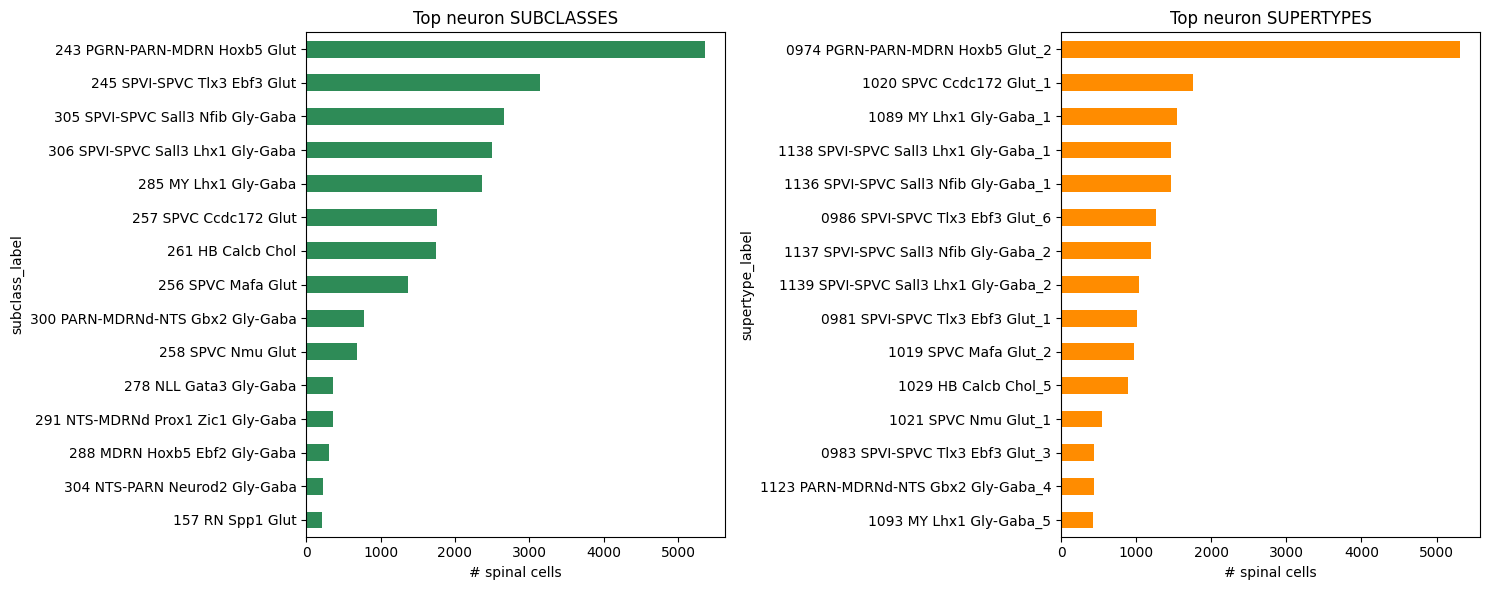

In [8]:
is_nn = mapping_df[WB_SUBCLASS_LEVEL].str.contains(' NN$', regex=True)
neuron_map = mapping_df[~is_nn]
print(f'{len(neuron_map)} / {len(mapping_df)} confident cells map to a NEURON subclass')

top_sub = neuron_map[WB_SUBCLASS_LEVEL].value_counts().head(15)
top_sup = neuron_map[WB_SUPERTYPE_LEVEL].value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top_sub[::-1].plot.barh(ax=axes[0], color='seagreen')
axes[0].set_xlabel('# spinal cells'); axes[0].set_title('Top neuron SUBCLASSES')
top_sup[::-1].plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('# spinal cells'); axes[1].set_title('Top neuron SUPERTYPES')
plt.tight_layout(); plt.show()
TOP_NEURON_SUBCLASSES = top_sub.index.tolist()

## 4. Where do the **mapped neuron types** live in the brain?

Now the payoff for the forward map: take the **most common neuron subclasses** your
spinal cord mapped to (§3) and **highlight exactly those** in the MERFISH atlas,
each in its own atlas colour, with everything else greyed out. Watch the
**hindbrain / medulla** and the **spinal-trigeminal** territory light up — the
parts of the brain whose neurons most resemble spinal cord.

highlighting 15 mapped neuron subclasses; 12614 atlas neurons painted (1.8% of neurons)


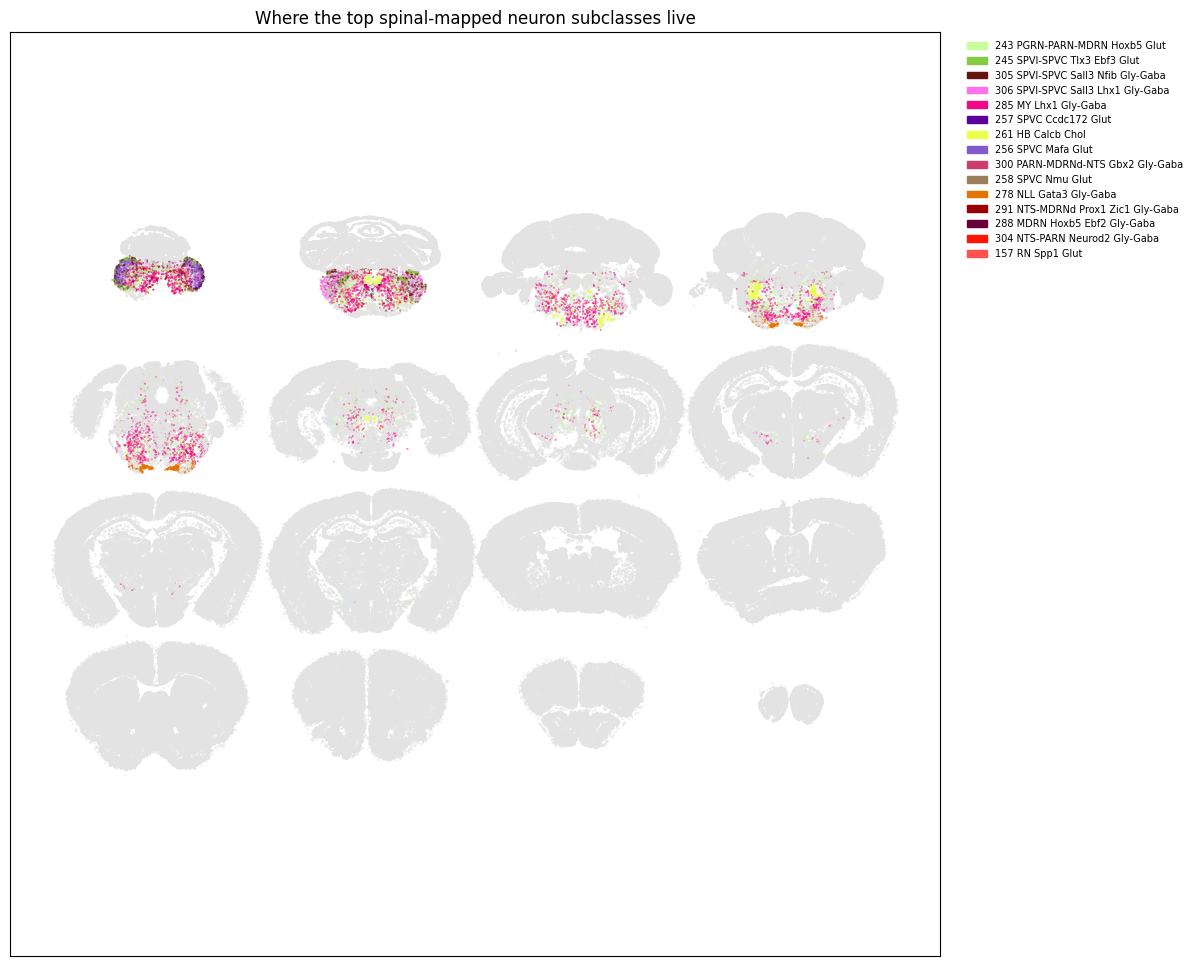

In [9]:
# Restrict the canvas to neuronal atlas cells (the 'NN' non-neurons are everywhere).
neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs.copy()

top_set = set(TOP_NEURON_SUBCLASSES)
o['mapped_subclass'] = o[ATLAS_SUBCLASS].astype(str).where(
    o[ATLAS_SUBCLASS].astype(str).isin(top_set))
# Each highlighted subclass in its OWN atlas colour; others grey.
sub_to_color = dict(zip(o[ATLAS_SUBCLASS].astype(str), o['subclass_color'].astype(str)))
GREY = '#e3e3e3'
colors = [sub_to_color.get(v, GREY) if isinstance(v, str) else GREY
          for v in o['mapped_subclass']]
print('highlighting', len(top_set), 'mapped neuron subclasses;',
      int(o['mapped_subclass'].notna().sum()), 'atlas neurons painted',
      f"({o['mapped_subclass'].notna().mean():.1%} of neurons)")

import matplotlib.patches as mpatches
fig, ax, _ = plot_section(o['x'], o['y'], cc=colors, s=0.3,
                          title='Where the top spinal-mapped neuron subclasses live')
ax.legend(handles=[mpatches.Patch(color=sub_to_color.get(c, GREY), label=c)
                   for c in TOP_NEURON_SUBCLASSES],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
plt.show()

---
## 5. Why map **both** ways? (the reciprocal refinement)

The forward map above has a built-in blind spot: a classifier can never answer
*"none of the above."* Every spinal nucleus is forced onto its nearest whole-brain
label, **even spinal cell types that have no real brain counterpart** — so a
one-way map will sprinkle spinal labels across cortex, thalamus, cerebellum, and
call it a day. High counts do not by themselves mean a genuine match.

The fix is to map **both directions** and keep only the pairs that **agree**:

* **Forward** (done above): spinal cells → whole-brain subclass.
* **Reverse**: each whole-brain subclass's mean profile → **our Session-1 (V2)
  spinal taxonomy**.
* **Reciprocal**: a whole-brain type is a real spinal analogue only if the spinal
  cells that map *to* it are the same spinal type it maps *back* to.

Requiring agreement in both directions raises **specificity** (spurious one-way
hits to cortex etc. drop out) without throwing away the genuine matches, which
agree both ways. The rest of the notebook builds and visualises that reciprocal
map.

> **Everything up to here (§1–§4) is dataset-agnostic** — it runs on *any*
> MapMyCells whole-mouse-brain result. **Everything below is specific to the
> workshop's spinal-cord Session-1 taxonomy** (it needs your V2 labels and the
> pre-built reverse map). If you mapped your own non-spinal data, you can stop
> here.

### Load your Session-1 spinal labels

Everything from here on needs the workshop's spinal-cord dataset: your Session-1
(V2) taxonomy labels and the pre-built reverse map. We load them now, attach each
mapped cell's own `Subclass_V2` / `Group_V2` by cell id, and pull the canonical V2
colour palettes so every reciprocal plot matches Session 1.

In [10]:
# Session-1 spinal-cord references — needed only for the reciprocal refinement.
QUERY_H5AD             = '/data/lipari_workshop/SpC_workshop_snRNA.h5ad'
REVERSE_JSON           = '/data/lipari_workshop/WB_SUBCLASS_to_SpC_MAPPING/hann_results.json'
SUPERTYPE_REVERSE_JSON = '/data/lipari_workshop/WB_SUPERTYPE_to_SpC_MAPPING/hann_results.json'
QUERY_SUBCLASS = 'Subclass_V2'   # our spinal subclass label
QUERY_GROUP    = 'Group_V2'      # our spinal group label
OVERLAP_MIN    = 0.50            # min Wilson-lower-bound overlap for "reciprocal"
for p in [QUERY_H5AD, REVERSE_JSON, SUPERTYPE_REVERSE_JSON]:
    print(f"{'OK ' if os.path.exists(p) else 'MISSING'} {p}")

# Attach each cell's OWN Session-1 labels (Subclass_V2 / Group_V2) by id.
adata_q = sc.read_h5ad(QUERY_H5AD, backed='r')
qobs = adata_q.obs[[QUERY_SUBCLASS, QUERY_GROUP]].copy()
mapping_df = mapping_df.join(qobs, how='left')
matched = int(mapping_df[QUERY_SUBCLASS].notna().sum())
print(f'attached Session-1 labels to {matched} / {len(mapping_df)} mapped cells')
if matched == 0:
    print('WARNING: no cell_ids matched the Session-1 query — the reciprocal half '
          'only applies to the workshop spinal-cord dataset, so the reverse/'
          'reciprocal cells below will be empty.')

# Canonical spinal-cord V2 colour palettes (label -> hex) straight from the query
# h5ad `uns`, so every Subclass_V2 / Group_V2 plot uses the SAME colours as
# Session 1. `uns['<key>_colors']` is aligned to the category order of obs['<key>'].
def load_palette(adata, key):
    cats = adata.obs[key].astype('category').cat.categories
    cols = list(adata.uns[f'{key}_colors'])
    return {c: cols[i] for i, c in enumerate(cats) if i < len(cols)}

SUBCLASS_PAL = load_palette(adata_q, QUERY_SUBCLASS)   # Subclass_V2 colours
GROUP_PAL = load_palette(adata_q, QUERY_GROUP)         # Group_V2 colours
print(f'loaded {len(SUBCLASS_PAL)} Subclass_V2 + {len(GROUP_PAL)} Group_V2 colours')

OK  /data/lipari_workshop/SpC_workshop_snRNA.h5ad
OK  /data/lipari_workshop/WB_SUBCLASS_to_SpC_MAPPING/hann_results.json
OK  /data/lipari_workshop/WB_SUPERTYPE_to_SpC_MAPPING/hann_results.json
attached Session-1 labels to 31234 / 31234 mapped cells
loaded 18 Subclass_V2 + 111 Group_V2 colours


### Forward summary by spinal subclass

Flip the forward map around: for each of **your** spinal subclasses, which
whole-brain subclass do its cells most often map to? This is the
per-spinal-subclass "forward best hit".

In [11]:
fwd_by_sub = mio.summarize_forward_by_query_level(
    mapping_df, qobs, QUERY_SUBCLASS, WB_SUBCLASS_LEVEL)
fwd_by_sub

,top_wb_subclass,top_frac,n_cells
Subclass_V2,,,
Glut-D,245 SPVI-SPVC Tlx3 Ebf3 Glut,0.361916,5761
GABA-D,306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,0.461342,4708
Glut-V,243 PGRN-PARN-MDRN Hoxb5 Glut,0.812899,3442
Glut-M,243 PGRN-PARN-MDRN Hoxb5 Glut,0.485561,2978
GABA-V,285 MY Lhx1 Gly-Gaba,0.445751,2977
GABA-M,285 MY Lhx1 Gly-Gaba,0.228128,2126
Myeloid,334 Microglia NN,0.443713,1368
Oligo,327 Oligo NN,0.874908,1359
vMN,261 HB Calcb Chol,0.678908,1062


## 6. Reverse — which whole-brain subclasses resemble a spinal type?

We pre-built a `cell_type_mapper` reference from **your Session-1 (V2)** spinal-cord
taxonomy (`Class_V2 → Subclass_V2 → Group_V2`) and mapped each whole-brain
subclass's mean expression onto it. Because the reference is *your* V2 taxonomy,
the reverse labels share the **same vocabulary** as the forward `Subclass_V2` /
`Group_V2`, so the two directions are directly comparable. (This reverse arm does
not depend on cell count, so it is shared rather than re-run on the portal.)

338 whole-brain subclasses mapped onto the spinal cord


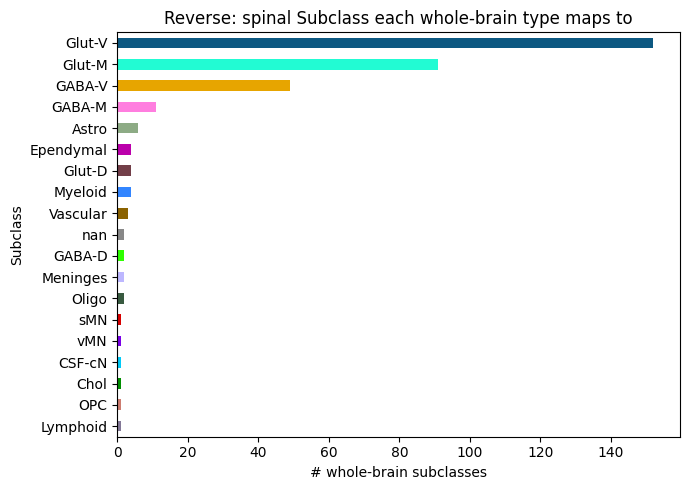

In [12]:
reverse_df = mio.load_mapping_results(
    REVERSE_JSON, levels=['Class', 'Subclass', 'Group'])
reverse_df.index.name = 'mouse_wb_subclass'
print(reverse_df.shape[0], 'whole-brain subclasses mapped onto the spinal cord')

fig, ax = plt.subplots(figsize=(7, 5))
vc = reverse_df['Subclass'].value_counts()[::-1]
vc.plot.barh(ax=ax, color=[SUBCLASS_PAL.get(s, '#888888') for s in vc.index])
ax.set_xlabel('# whole-brain subclasses')
ax.set_title('Reverse: spinal Subclass each whole-brain type maps to')
plt.tight_layout(); plt.show()

## 7. Reciprocal subclasses (overlap coefficient + support discount)

Now combine the two arms. For each whole-brain subclass `M` we take its best
spinal-subclass partner by **overlap coefficient** (Szymkiewicz–Simpson):

$$\mathrm{OC}(S, M) = \frac{|A \cap B|}{\min(|A|, |B|)}$$

where `A` = the spinal cells of subclass `S` and `B` = the spinal cells mapped to
`M`. `OC = 1` means one set sits inside the other; `OC ≈ 0` means they barely
co-occur. **The catch:** OC saturates at 1 on tiny samples, so a handful of cells
sharing a label fakes a perfect match. We therefore gate on its **Wilson score
lower bound** `overlap_lb` (with `n = min(|A|, |B|)`), which shrinks low-`n`
overlaps toward 0. A pair is **reciprocal** when both arms name the same spinal
subclass **and** `overlap_lb ≥ OVERLAP_MIN` (= 0.50). We compute this **live** from
your portal mapping, so it reflects exactly the cells you uploaded.

In [13]:
sub_ov = mio.reciprocal_subclass_overlap(
    mapping_df, qobs, reverse_df,
    query_subclass_key=QUERY_SUBCLASS, wb_subclass_level=WB_SUBCLASS_LEVEL,
    rev_subclass_level='Subclass', rev_group_level='Group',
    min_overlap=OVERLAP_MIN, wilson_z=1.96)
n_rec = int(sub_ov['reciprocal'].sum())
print(f"{n_rec} of {len(sub_ov)} whole-brain subclasses are reciprocal "
      f"(agree both ways AND overlap_lb >= {OVERLAP_MIN}).")
# Note how overlap_lb pulls down the low-n_spc_cells rows relative to raw overlap.
sub_ov.sort_values('overlap_lb', ascending=False).head(15)[
    ['n_spc_cells', 'fwd_spc_subclass', 'overlap', 'overlap_lb',
     'rev_spc_subclass', 'reciprocal']]

46 of 155 whole-brain subclasses are reciprocal (agree both ways AND overlap_lb >= 0.5).


,n_spc_cells,fwd_spc_subclass,overlap,overlap_lb,rev_spc_subclass,reciprocal
subclass_label,,,,,,
257 SPVC Ccdc172 Glut,1759,Glut-D,0.998294,0.994997,Glut-D,True
261 HB Calcb Chol,1750,sMN,0.998937,0.994005,sMN,True
258 SPVC Nmu Glut,688,Glut-D,0.998547,0.991813,Glut-D,True
331 Peri NN,247,Vascular,1.000000,0.984685,Vascular,True
333 Endo NN,319,Vascular,0.996865,0.982459,Vascular,True
323 Ependymal NN,378,Ependymal,0.994709,0.980916,Ependymal,True
329 ABC NN,249,Meninges,0.991968,0.971192,Meninges,True
307 RO-RPA Pkd2l1 Gaba,185,CSF-cN,0.989189,0.961445,CSF-cN,True
304 NTS-PARN Neurod2 Gly-Gaba,229,GABA-M,0.978166,0.949915,GABA-M,True


### Reciprocal mapping heatmap (subclass level)

The full overlap-coefficient matrix (spinal subclasses × whole-brain subclasses),
shown for the **reciprocal** whole-brain subclasses, grouped by the spinal subclass
they reciprocate with. Spinal columns stay in a fixed order; the whole-brain rows
are reordered to drive the bright cells onto the diagonal. Read down the `Glut-D`
column to see every brainstem dorsal-horn-like subclass.

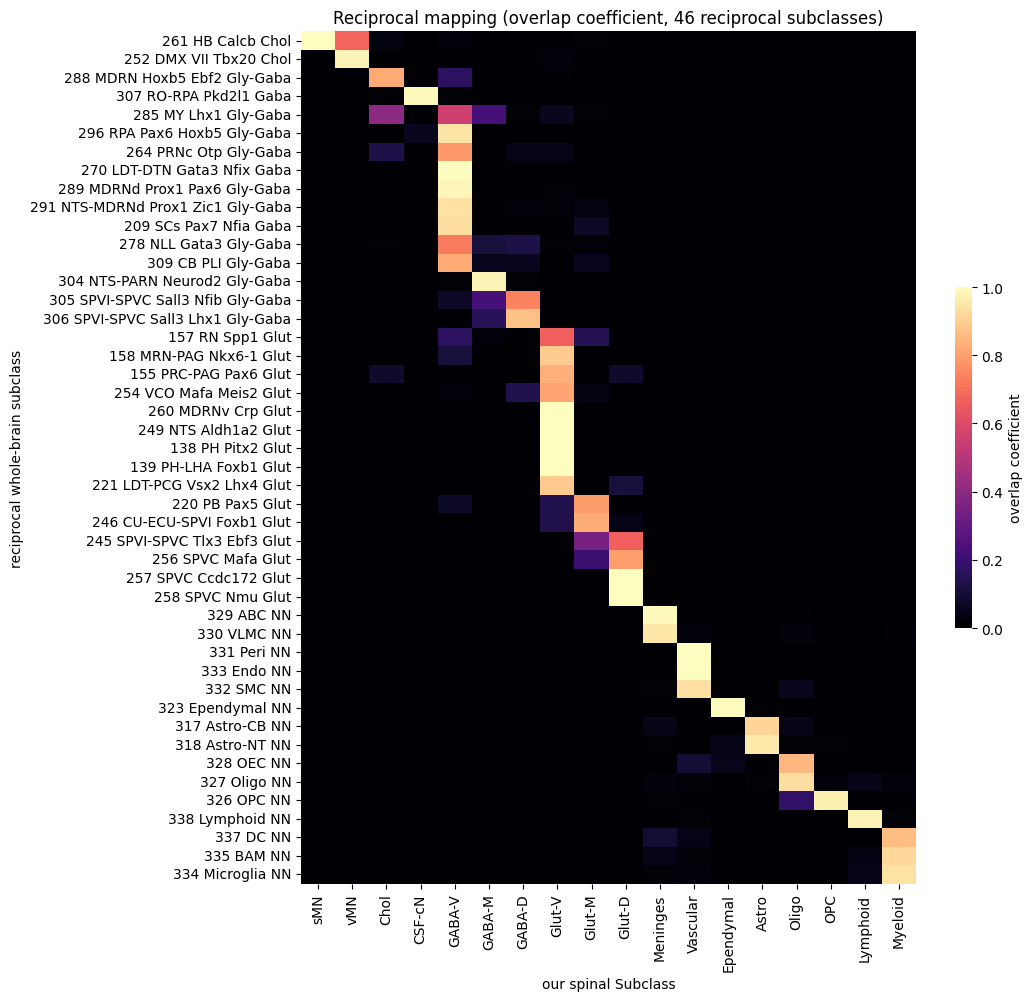

In [14]:
def diagonal_row_order(M):
    """Row order that maximizes diagonality for a FIXED column order: sort rows
    by their intensity-weighted mean column (barycenter)."""
    A = M.to_numpy(float); w = A.sum(1); cols = np.arange(A.shape[1])
    bary = np.where(w > 0, (A * cols).sum(1) / np.where(w > 0, w, 1.0), A.shape[1])
    keys = np.lexsort((-A.max(1), A.argmax(1), bary))   # primary = barycenter
    return M.index[keys]

oc = mio.overlap_coefficient_matrix(mapping_df, qobs, QUERY_SUBCLASS,
                                    WB_SUBCLASS_LEVEL)            # spinal × WB
rec_wb = [m for m in sub_ov.index[sub_ov['reciprocal']] if m in oc.columns]
spc_cols = [c for c in oc.index if c in set(sub_ov.loc[rec_wb, 'fwd_spc_subclass'])]
H = oc.loc[spc_cols, rec_wb].T                                   # WB(rows) × spinal(cols)
H = H.loc[diagonal_row_order(H)]    # reorder WB rows for diagonality; columns fixed

fig, ax = plt.subplots(figsize=(1.0 + 0.55 * len(spc_cols), max(6, 0.22 * len(H))))
sns.heatmap(H, cmap='magma', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'overlap coefficient', 'shrink': 0.4})
ax.set_xlabel('our spinal Subclass'); ax.set_ylabel('reciprocal whole-brain subclass')
ax.set_title(f'Reciprocal mapping (overlap coefficient, {len(H)} reciprocal subclasses)')
plt.tight_layout(); plt.show()

## 8. Finer grain: reciprocal **supertypes**

Step both sides down a level: the whole-brain **supertype** (finer than subclass)
against our spinal **`Group_V2`** (finer than Subclass_V2). The portal already gave
every cell a supertype, so we know each supertype's parent subclass; a supertype is
**reciprocal** when the spinal `Group_V2` it maps back to (reverse arm at supertype
resolution) matches the forward best-matching `Group_V2` of its parent subclass,
inheriting the same `overlap_lb ≥ OVERLAP_MIN` support gate. Computed live from your
portal mapping.

In [15]:
# Reverse arm at supertype resolution (shared reference, V2 vocabulary).
st_rev = mio.load_mapping_results(
    SUPERTYPE_REVERSE_JSON, levels=['Class', 'Subclass', 'Group'])

# supertype -> parent subclass, straight from the portal taxonomy columns.
s2s = (mapping_df.groupby(WB_SUPERTYPE_LEVEL)[WB_SUBCLASS_LEVEL]
       .agg(lambda s: s.value_counts().index[0]).rename('subclass_label').to_frame())
s2s.index.name = 'supertype'

# Forward best spinal Group_V2 per whole-brain subclass (support-discounted).
fwd_grp = mio.forward_best_partner(mapping_df, qobs, QUERY_GROUP, WB_SUBCLASS_LEVEL)

st_recip = mio.reciprocal_supertypes(st_rev, s2s, fwd_grp,
                                     rev_group_level='Group', min_overlap=OVERLAP_MIN)
n_st = int(st_recip['reciprocal'].sum())
print(f"{n_st} of {len(st_recip)} whole-brain supertypes are reciprocal.")
by_spc = (st_recip[st_recip['reciprocal']]
          .groupby('fwd_spc_group').size().sort_values(ascending=False))
print('\nReciprocal supertypes per spinal Group_V2:'); print(by_spc)
st_recip[st_recip['reciprocal']].sort_values('overlap_lb', ascending=False).head(15)[
    ['parent_wb_subclass', 'fwd_spc_group', 'rev_spc_group', 'overlap', 'overlap_lb']]

41 of 279 whole-brain supertypes are reciprocal.

Reciprocal supertypes per spinal Group_V2:
fwd_spc_group
NN THEMIS Lymphocyte            3
NN OPALIN Oligo                 2
NN PDGFRA OPC                   2
NN SLC38A11 Peri-SMC            2
NN COL5A1 VLMC                  2
Sp10 RNF220 Glut                2
Sp GATA3 GABA-Gly               2
aMN-ff CHODL Chol               2
Sp5M SLC17A7 Glut               2
NN SLC7A10 GM-Astro             2
NN FAM81 Ependymal              2
NN CLDN5 Endo                   1
NN AIF1 Microglia               1
NN MPZ Schwann                  1
NN DCN ABC                      1
NN DPP4 Monocyte                1
NN F13A1 Macrophage             1
CSF-cN PKD2L1 GABA-Gly          1
LSp1,3 NPY ECEL1 GABA-Gly       1
Sp1-2 CADPS2 PLCL1 Glut         1
Sp2-3 FOXO1 ADAMTS5 GABA        1
Sp2o NMUR2 Glut                 1
Sp2i NMU TAC3 Glut              1
Sp4L MAF Glut                   1
Sp5 BNC2 PIEZO2 Glut            1
Sp5-6 NR4A2 DLK1 Glut           1
Sp5 POU4F

,parent_wb_subclass,fwd_spc_group,rev_spc_group,overlap,overlap_lb
supertype,,,,,
1184 MOL NN_4,327 Oligo NN,NN OPALIN Oligo,NN OPALIN Oligo,1.000000,0.990487
1183 MFOL NN_3,327 Oligo NN,NN OPALIN Oligo,NN OPALIN Oligo,1.000000,0.990487
0986 SPVI-SPVC Tlx3 Ebf3 Glut_6,245 SPVI-SPVC Tlx3 Ebf3 Glut,Sp1-2 CADPS2 PLCL1 Glut,Sp1-2 CADPS2 PLCL1 Glut,0.997268,0.984688
1026 HB Calcb Chol_2,261 HB Calcb Chol,aMN-ff CHODL Chol,aMN-ff CHODL Chol,1.000000,0.983711
1027 HB Calcb Chol_3,261 HB Calcb Chol,aMN-ff CHODL Chol,aMN-ff CHODL Chol,1.000000,0.983711
1020 SPVC Ccdc172 Glut_1,257 SPVC Ccdc172 Glut,Sp2o NMUR2 Glut,Sp2o NMUR2 Glut,0.994949,0.981774
1176 Ependymal NN_2,323 Ependymal NN,NN FAM81 Ependymal,NN FAM81 Ependymal,0.994709,0.980916
1175 Ependymal NN_1,323 Ependymal NN,NN FAM81 Ependymal,NN FAM81 Ependymal,0.994709,0.980916
1139 SPVI-SPVC Sall3 Lhx1 Gly-Gaba_2,306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,Sp2-3 FOXO1 ADAMTS5 GABA,Sp2-3 FOXO1 ADAMTS5 GABA,0.992366,0.977800


### Supertype mapping confidence — and the same 0.5 filter

Each whole-brain **supertype** mean was mapped onto our V2 spinal reference; the
`Group_V2` **bootstrapping probability** grades how stable each supertype→Group
call is. Exactly as for the forward arm (§2) we keep only supertypes whose call
clears `MIN_PROB` (= 0.5), so **both** directions are confidence-filtered at the
same threshold.

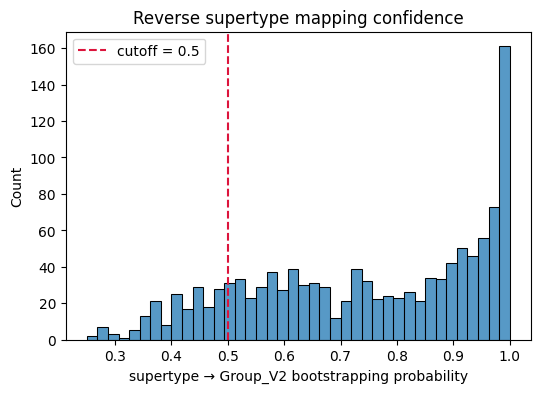

kept 1024 / 1201 supertypes at prob >= 0.5; median = 0.84


In [16]:
gp = 'Group_prob'
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(st_rev[gp], bins=40, ax=ax)
ax.axvline(MIN_PROB, color='crimson', ls='--', lw=1.5, label=f'cutoff = {MIN_PROB}')
ax.set_xlabel('supertype → Group_V2 bootstrapping probability')
ax.set_title('Reverse supertype mapping confidence'); ax.legend()
plt.show()
n_before = len(st_rev)
st_rev_conf = st_rev[st_rev[gp] >= MIN_PROB]
print(f'kept {len(st_rev_conf)} / {n_before} supertypes at prob >= {MIN_PROB}; '
      f'median = {round(float(st_rev_conf[gp].median()), 3)}')

### Reciprocal mapping heatmap (supertype level)

The supertype analogue of §7. Rows are the **reciprocal whole-brain supertypes**
that also pass the confidence filter; columns are the spinal **`Group_V2`** they
reciprocate with (fixed order). Each cell is shaded by the supertype→Group
bootstrapping probability, with the supertype **rows reordered for diagonality**.

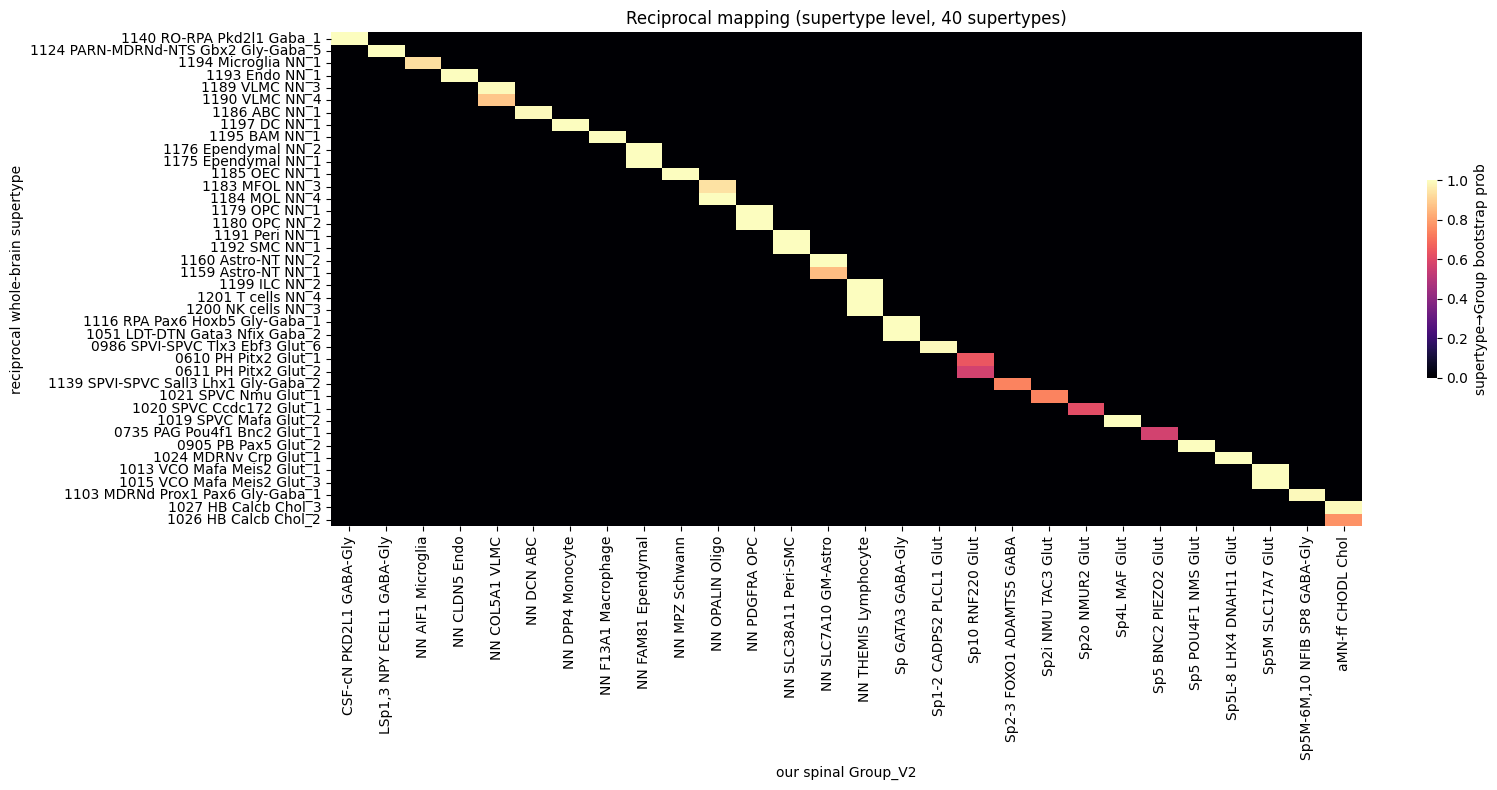

In [17]:
st_rt = st_recip[st_recip['reciprocal']].copy()
st_rt = st_rt.loc[st_rt.index.intersection(st_rev_conf.index)]   # confident only
spc_groups = sorted(set(st_rt['fwd_spc_group']))                 # spinal cols, fixed order
M = pd.DataFrame(0.0, index=st_rt.index, columns=spc_groups)
for t, r in st_rt.iterrows():
    g = r['fwd_spc_group']                                       # == rev group (reciprocal)
    if g in M.columns:
        M.at[t, g] = float(st_rev.at[t, 'Group_prob'])
M = M.loc[diagonal_row_order(M)]    # reorder supertype rows for diagonality

fig, ax = plt.subplots(figsize=(1.0 + 0.55 * len(spc_groups), max(6, 0.20 * len(M))))
sns.heatmap(M, cmap='magma', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'supertype→Group bootstrap prob', 'shrink': 0.4})
ax.set_xlabel('our spinal Group_V2'); ax.set_ylabel('reciprocal whole-brain supertype')
ax.set_title(f'Reciprocal mapping (supertype level, {len(M)} supertypes)')
plt.tight_layout(); plt.show()

## 9. Where do the **reciprocal** subclasses live? (neurons only)

Compare with §4: there we painted every top forward hit; here we paint only the
subclasses that survive the **reciprocal** test, coloured by the spinal **Subclass**
they reciprocate with (`Glut-D` dorsal, `Glut-V` ventral, `GABA-*` inhibitory, …).
The spurious one-way hits are gone, leaving a cleaner picture concentrated in the
**hindbrain / medulla** and **spinal-trigeminal** territory.

reciprocal subclasses: 46 | painted 16766 neuronal cells (2.4% of neurons)


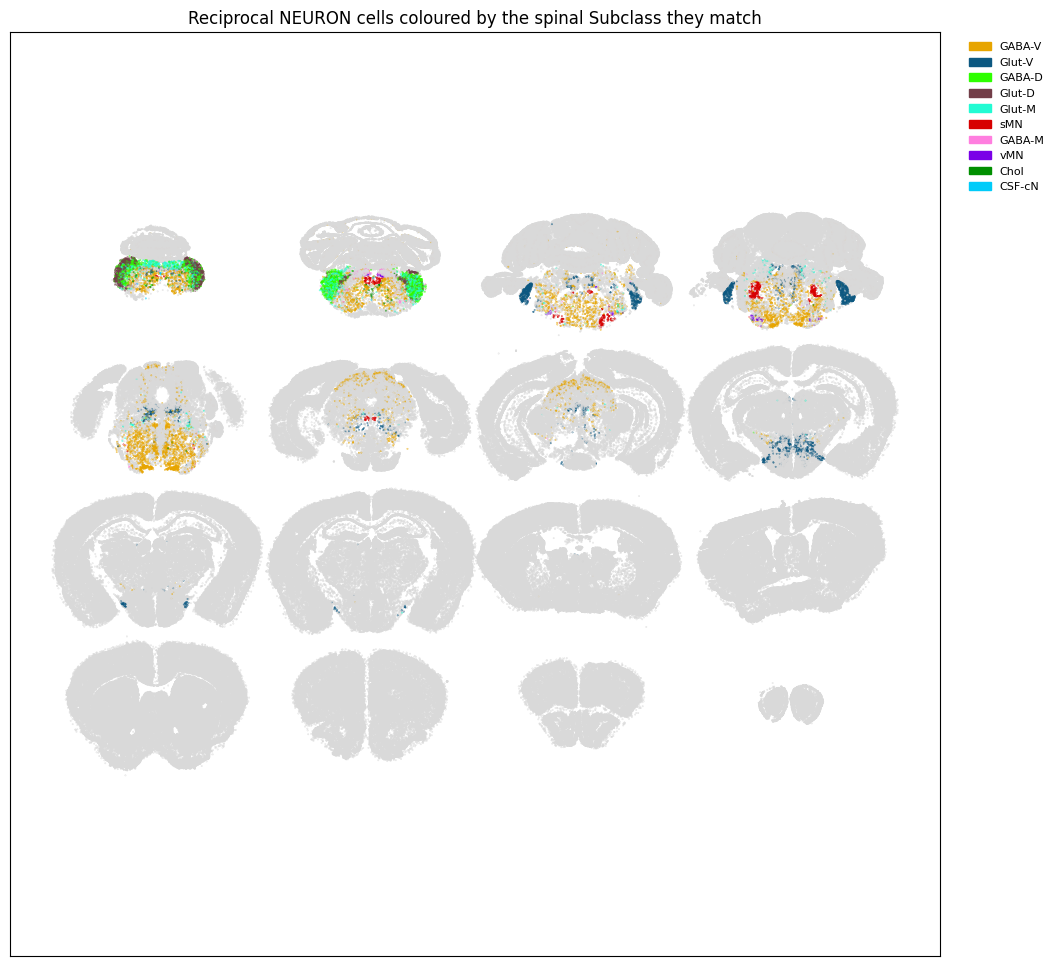

In [18]:
recip_set = set(sub_ov.index[sub_ov['reciprocal']])
sub_map = sub_ov.loc[sub_ov['reciprocal'], 'fwd_spc_subclass'].to_dict()
# Full-atlas reciprocal flag for the CCF region tabulation in §10.
adata_atlas.obs['is_reciprocal'] = (
    adata_atlas.obs[ATLAS_SUBCLASS].astype(str).isin(recip_set))

neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs.copy()
o['recip_spc_subclass'] = o[ATLAS_SUBCLASS].astype(str).map(sub_map)
print('reciprocal subclasses:', len(recip_set), '| painted',
      int(o['recip_spc_subclass'].notna().sum()), 'neuronal cells',
      f"({o['recip_spc_subclass'].notna().mean():.1%} of neurons)")

cats = o['recip_spc_subclass'].dropna().value_counts().head(10).index.tolist()
palette = {c: SUBCLASS_PAL.get(c, '#dddddd') for c in cats}   # canonical Subclass_V2 colours
GREY = '#d9d9d9'
colors = [palette[v] if (isinstance(v, str) and v in palette) else GREY
          for v in o['recip_spc_subclass']]
fig, ax, _ = plot_section(o['x'], o['y'], cc=colors, s=0.3,
                          title='Reciprocal NEURON cells coloured by the spinal Subclass they match')
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=palette[c], label=c) for c in cats],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=False)
plt.show()

## 9b. Reciprocal **neuron** supertypes in space

The finest grain — neurons only. Each reciprocal supertype (§8) carries a specific
spinal `Group_V2`; we drop the non-neuronal `NN …` groups (which blanket the whole
brain) and colour the neuronal canvas by the spinal **`Group_V2`** each reciprocal
supertype matches, so specific dorsal / ventral neuronal territories stand out.

20 reciprocal NEURON supertypes; painted 4015 neuronal cells (0.6% of neurons)


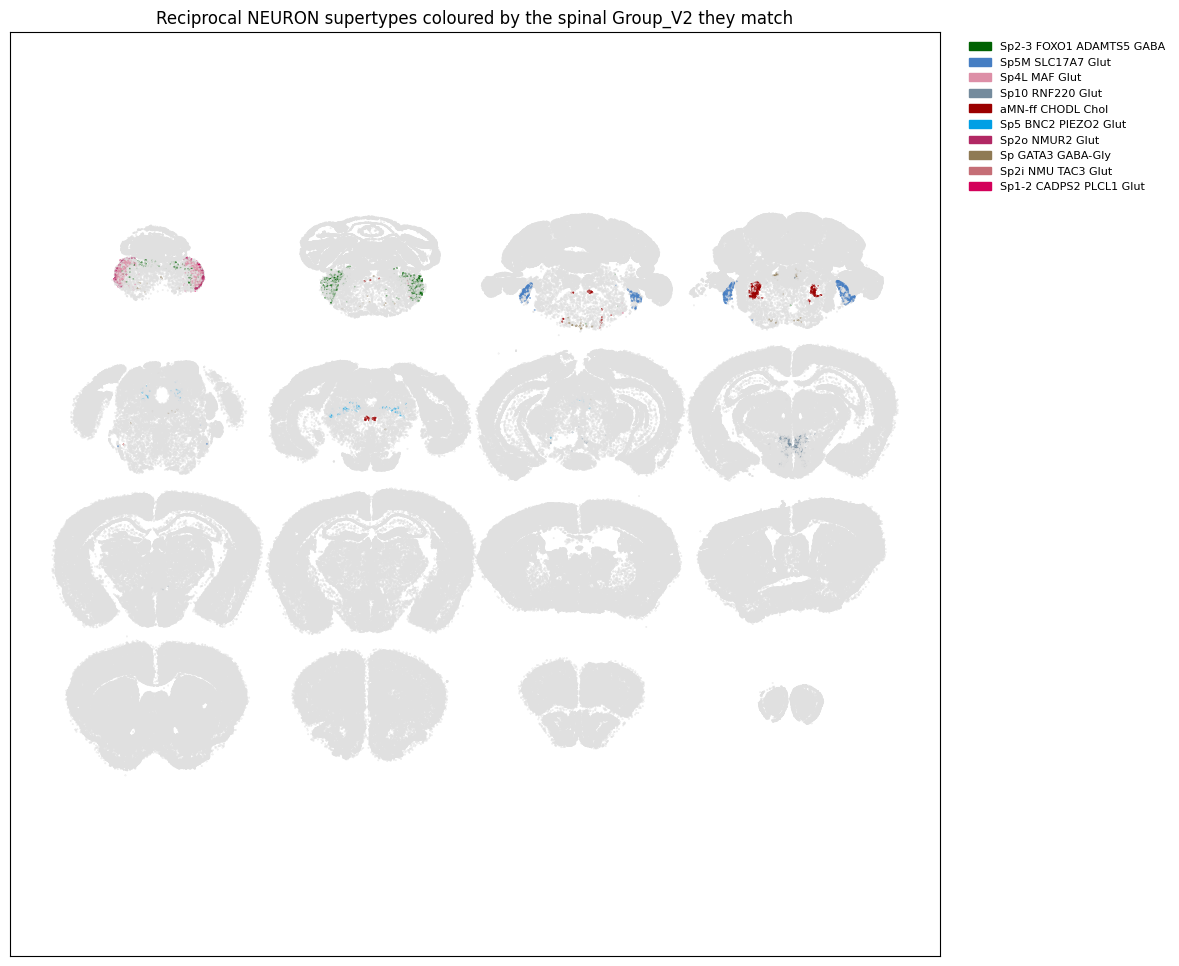

In [19]:
recip_super = {t: g for t, g in zip(st_recip.index[st_recip['reciprocal']],
                                    st_recip.loc[st_recip['reciprocal'], 'fwd_spc_group'])
               if not str(g).startswith('NN ')}
neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs.copy()
o['is_recip_supertype'] = o[ATLAS_SUPERTYPE].astype(str).isin(recip_super)
o['recip_super_spc'] = o[ATLAS_SUPERTYPE].astype(str).map(recip_super)
print(f"{len(recip_super)} reciprocal NEURON supertypes;",
      'painted', int(o['is_recip_supertype'].sum()), 'neuronal cells',
      f"({o['is_recip_supertype'].mean():.1%} of neurons)")

cats2 = o['recip_super_spc'].dropna().value_counts().head(10).index.tolist()
pal2 = {c: GROUP_PAL.get(c, '#dddddd') for c in cats2}        # canonical Group_V2 colours
colors2 = [pal2[v] if (isinstance(v, str) and v in pal2) else '#e0e0e0'
           for v in o['recip_super_spc']]
fig, ax, _ = plot_section(o['x'], o['y'], cc=colors2, s=0.3,
                          title='Reciprocal NEURON supertypes coloured by the spinal Group_V2 they match')
ax.legend(handles=[mpatches.Patch(color=pal2[c], label=c) for c in cats2],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=False)
plt.show()

## 10. Which brain regions are the reciprocal types in? (neurons only)

Cross-tabulate the reciprocal cells against their **CCF region** (anatomical
parcellation) to name the structures most spinal-cord-like in transcriptome. We
keep **neurons only** (drop the `… NN` non-neuronal subclasses, which sit in every
region) so the region tally reflects genuine neuronal correspondence.

In [ ]:
recip_cells = adata_atlas.obs[
    adata_atlas.obs['is_reciprocal']
    & ~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
region = (recip_cells['parcellation_division'].astype(str)
          .value_counts().head(15))
fig, ax = plt.subplots(figsize=(7, 5))
region[::-1].plot.barh(ax=ax, color='teal')
ax.set_xlabel('# reciprocal neuronal cells')
ax.set_title('CCF divisions of the reciprocal spinal-like NEURONS')
plt.tight_layout(); plt.show()
region

## 11. Exercise & discussion

You mapped your spinal cord to the whole brain on the **MapMyCells portal**, found
the neuron types it most resembles, and saw where they sit — then sharpened the
picture by mapping both ways. Discuss / explore:

1. **Forward vs reciprocal.** Compare §4 (all top forward hits) with §9 (reciprocal
   only). Which highlighted regions **disappeared** once you required two-way
   agreement? Those were the one-way "false positives" — the map could not say *no*.
2. **Dorsal horn analogue.** `SPVI-SPVC Tlx3 … Glut` is reciprocal with spinal
   `Glut-D` (`Tlx3` = the canonical dorsal-horn excitatory selector). Which CCF
   division did these fall in (§10)? Why does the *spinal-trigeminal nucleus*
   resemble the dorsal horn?
3. **Confidence.** Re-make the §3 confidence histogram split by `Class_V2`
   (`adata_q.obs`). Do non-neuronal cells map more confidently than neurons?
4. **Your own data.** Swap `PORTAL_OUTPUT` in §0 for a different MapMyCells run and
   re-execute — every figure updates from the new portal download.

---
*Forward mapping: **MapMyCells** web portal, 10x Whole Mouse Brain (`CCN20230722`),
Hierarchical algorithm. Reverse reference: our Session-1 (V2) spinal-cord taxonomy
(`cell_type_mapper`). Spatial atlas: ABC MERFISH `C57BL6J-638850`.*